# Draft Submission Training Notebook

This notebook covers Exploratory Data Analysis (EDA) and trains both the Linear and MLP models. It includes setup instructions for running on Google Colab.

## Colab Setup
Run the following cell to clone the repository and install the required dependencies.

All configurations are included in the repo at `configs/a1/`

In [1]:
!git clone --branch a1-draft-test https://github.com/TuanKhai1210/Deep-Learning-Benchmark-Suite.git
%cd Deep-Learning-Benchmark-Suite
!pip install -e .

Cloning into 'Deep-Learning-Benchmark-Suite'...
remote: Enumerating objects: 951, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 951 (delta 31), reused 55 (delta 17), pack-reused 842 (from 1)
Receiving objects: 100% (951/951), 2.18 MiB | 5.22 MiB/s, done.
Resolving deltas: 100% (500/500), done.
/content/Deep-Learning-Benchmark-Suite
Obtaining file:///content/Deep-Learning-Benchmark-Suite
  Preparing metadata (setup.py) ... done
  Running setup.py develop for deep-learning-benchmark-suite


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/dlbench_runs"

In [ ]:
from pathlib import Path

project_root = Path(".").resolve()

repo_runs_dir = project_root / "runs"
drive_dlbench_runs_dir = Path("/content/drive/MyDrive/dlbench_runs")

# Remove the existing 'runs' directory if it's not already a symlink
if repo_runs_dir.exists() and not repo_runs_dir.is_symlink():
    !rm -rf {repo_runs_dir}

# Create a symbolic link from the runs folder to the Google Drive directory
!ln -s {drive_dlbench_runs_dir} {repo_runs_dir}

print(f"Symlink created: {repo_runs_dir} -> {repo_runs_dir.resolve()}")

Symlink created: /content/Deep-Learning-Benchmark-Suite/runs -> /content/drive/MyDrive/dlbench_runs


In [ ]:
import sys
import json
import pprint
from pathlib import Path
from IPython.display import Image, display

# Add the project root to sys.path so we can import from src
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

In [ ]:
from dlbench.common.config import load_config
from dlbench.a1.data.dataset import prepare_data
from dlbench.a1.data.loaders import build_dataloaders
from dlbench.a1.data.eda import generate_eda
from dlbench.a1.trainer import fit, evaluate_checkpoint

## Load Configurations
Load and display the configuration files for both Linear and MLP models. These config files define the data parameters, splits, model seeds, and hyperparameters.

All model configs are located in `configs/a1/models/<model_name>.py`

In [ ]:
linear_config_file = project_root / "configs" / "a1" / "models" / "linear.py"
linear_config = load_config(linear_config_file)

In [ ]:
mlp_config_file = project_root / "configs" / "a1" / "models" / "mlp.py"
mlp_config = load_config(mlp_config_file)

## Exploratory Data Analysis (EDA)
We will use the EDA module to extract dataset statistics, generate distribution plots, and verify splits.

In [ ]:
eda_output_dir = project_root / "runs" / "eda"
# Using linear_config, but data config is shared between models
prepare_data(linear_config)
generate_eda(linear_config, output_dir=eda_output_dir)

print(f"EDA statistics saved to folder {eda_output_dir}")

# Show EDA Stats
with open(eda_output_dir / "eda_summary.json", "r") as f:
    eda_stats = json.load(f)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.7MB/s]


EDA statistics saved to folder /content/Deep-Learning-Benchmark-Suite/runs/eda


In [ ]:
print(f"\nInput Size (Image Shape): {eda_stats.get('image_shape')}")
print(f"Channels: {eda_stats.get('channels')}")
print(f"Train size: {eda_stats.get('split').get('train_size')}")
print(f"Validation size: {eda_stats.get('split').get('validation_size')}")
print(f"Test size: {eda_stats.get('split').get('test_size')}")


Input Size (Image Shape): [28, 28]
Channels: 1
Train size: 50000
Validation size: 10000
Test size: 10000


## Class distribution plot accross training/validation/test set

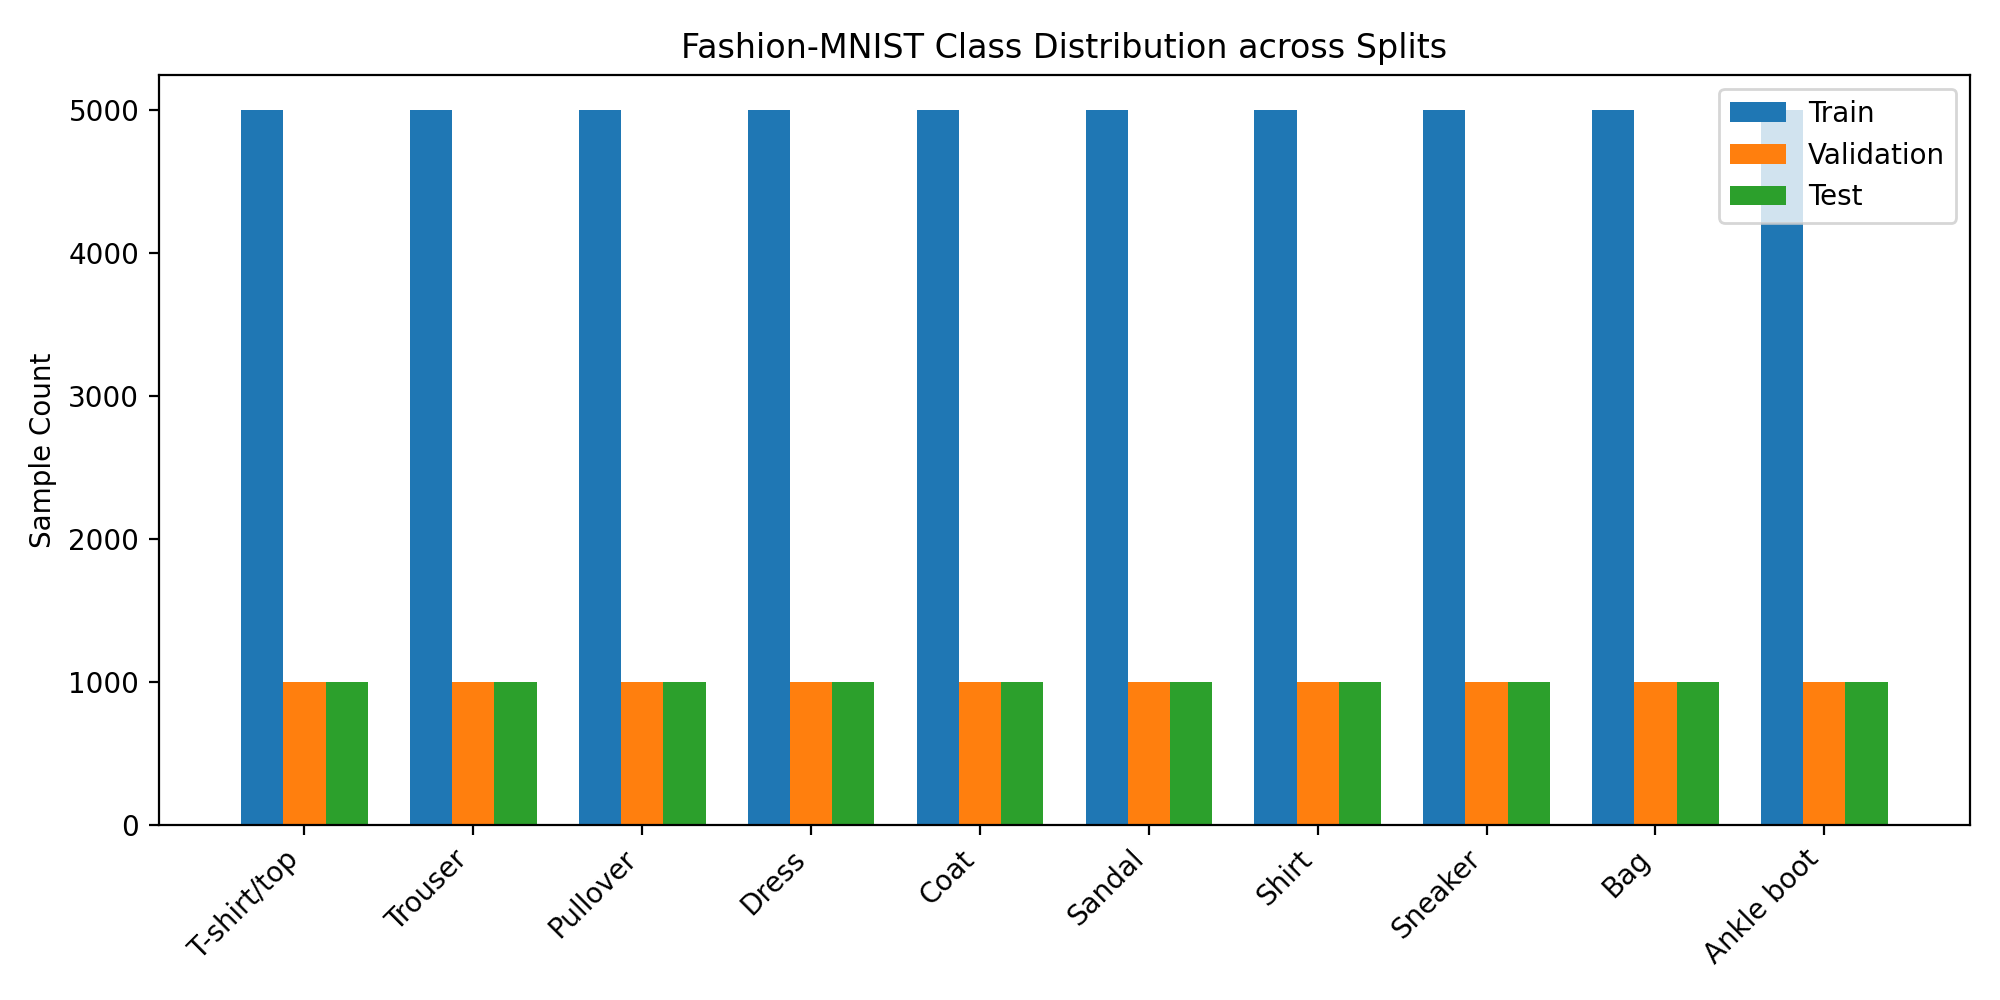

In [ ]:
display(Image(filename=str(eda_output_dir / "class_distribution.png"), width=1000))

## Representative samples

Display all representative sample grids, one for each class


Representative Samples for Class 0:


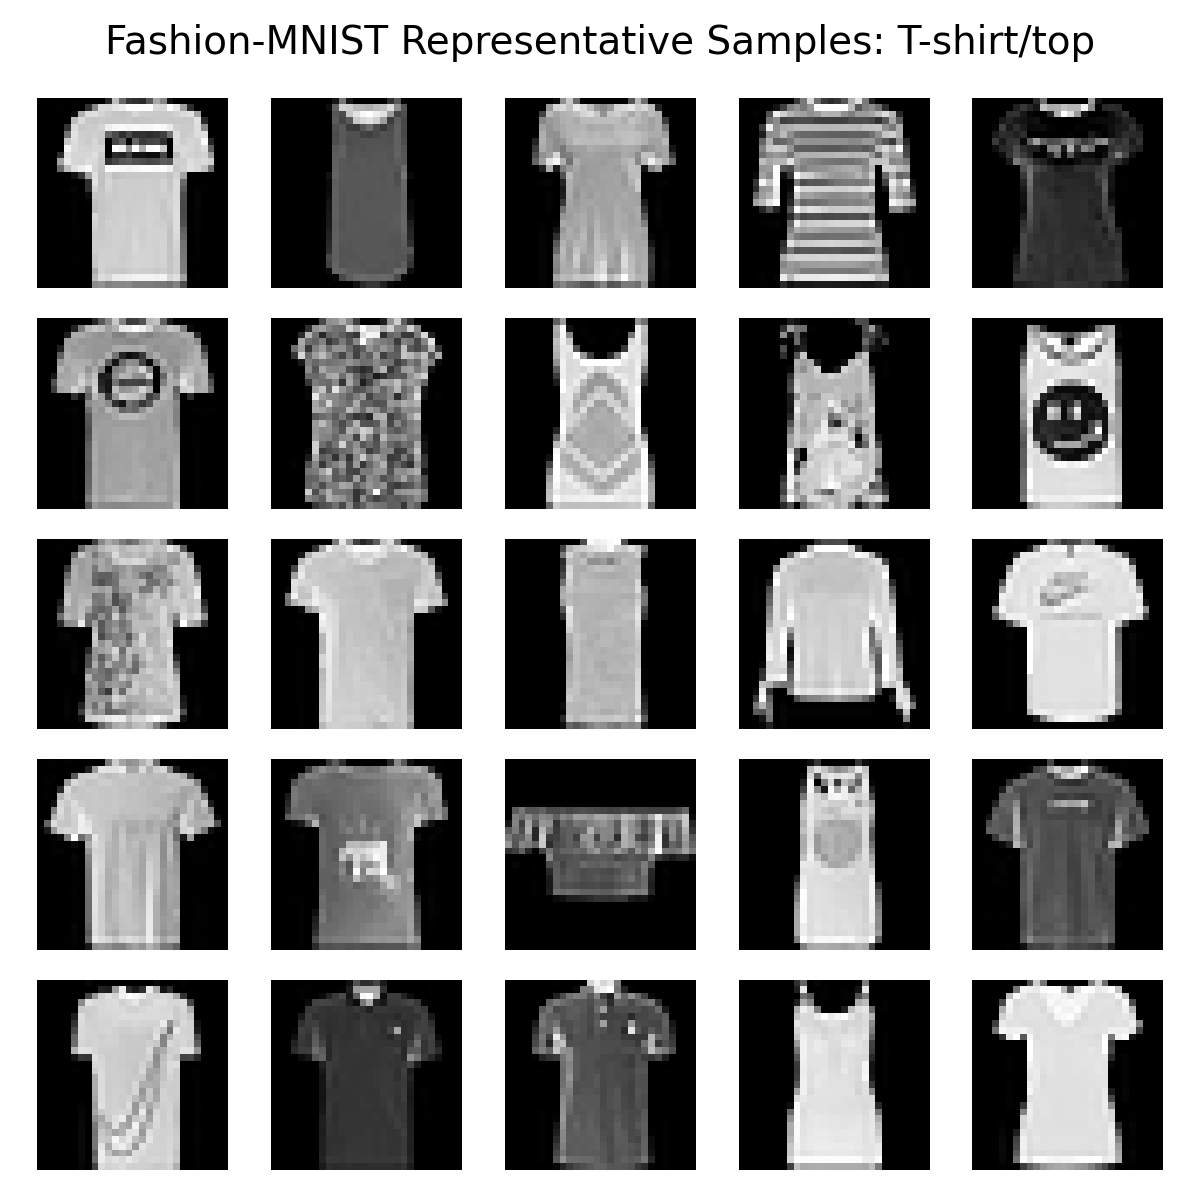


Representative Samples for Class 1:


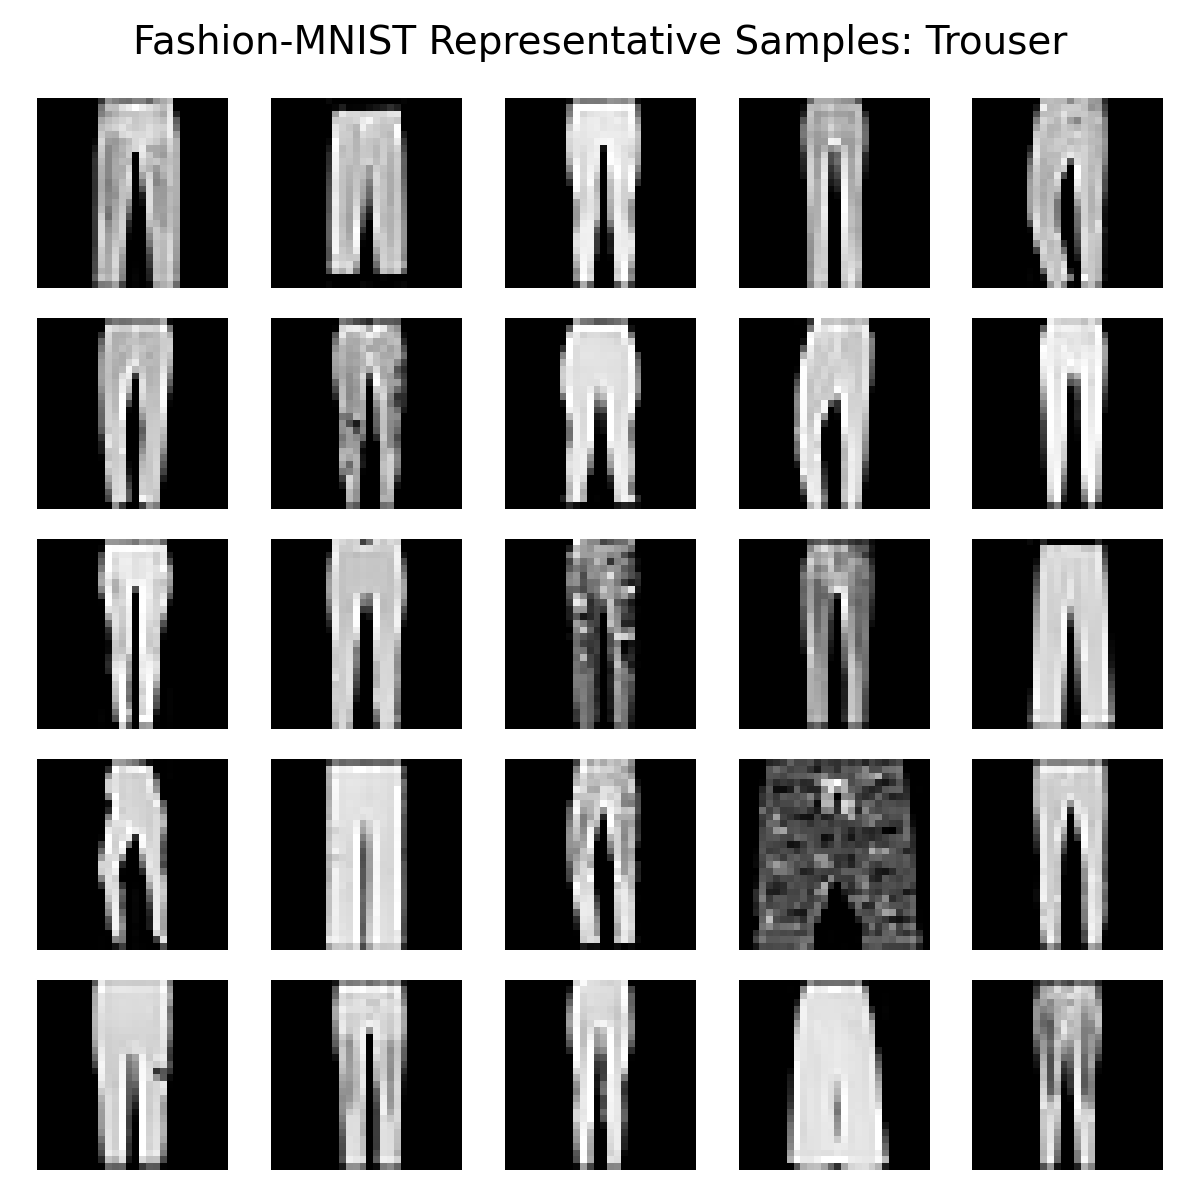


Representative Samples for Class 2:


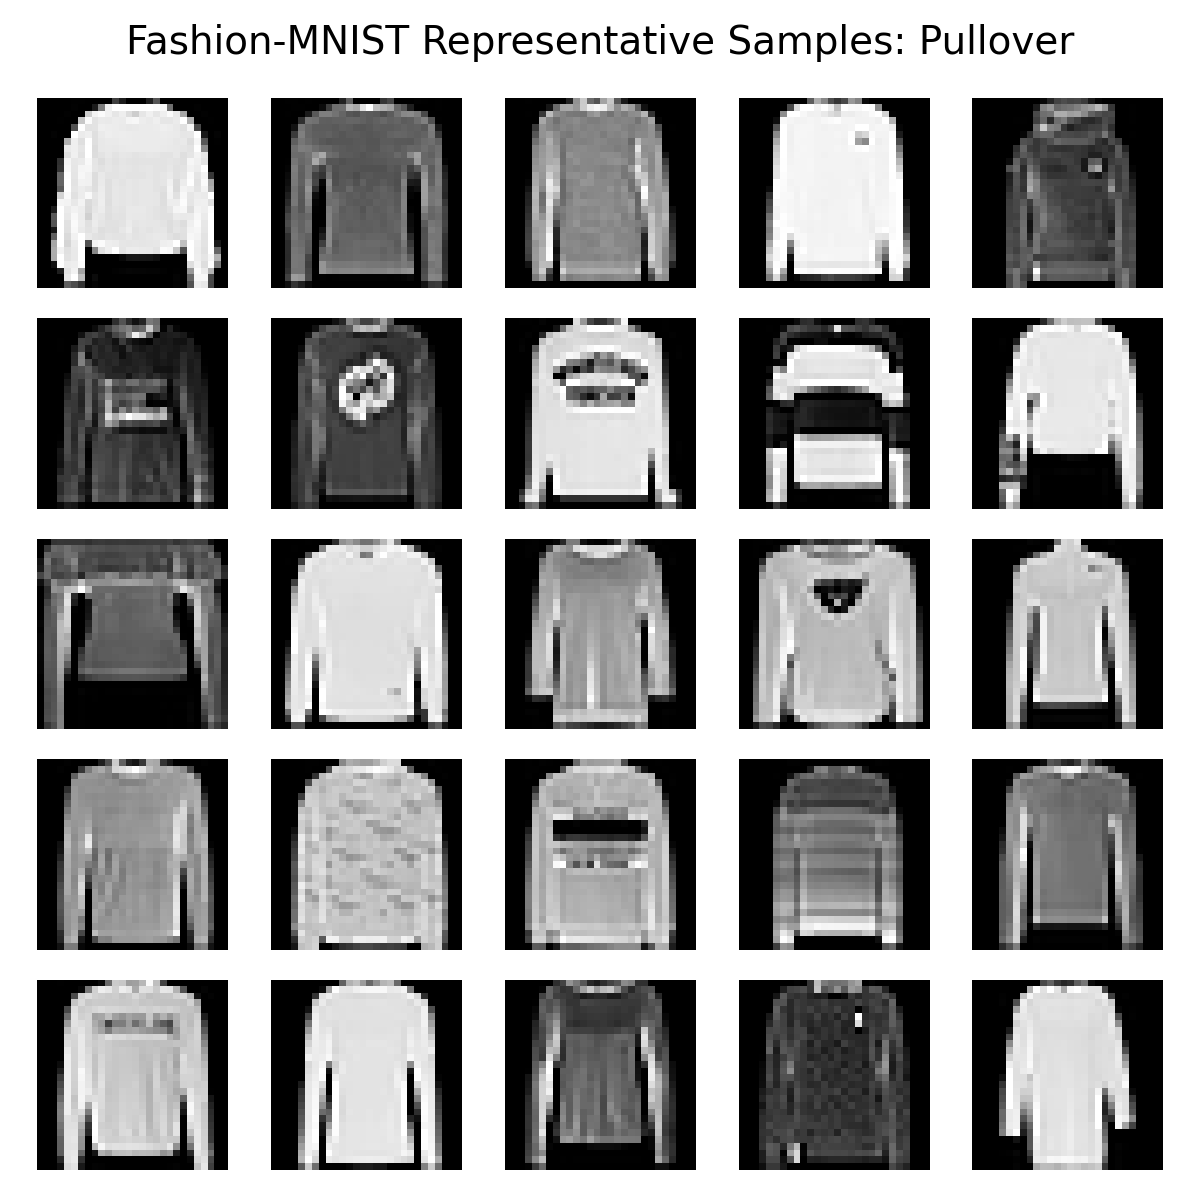


Representative Samples for Class 3:


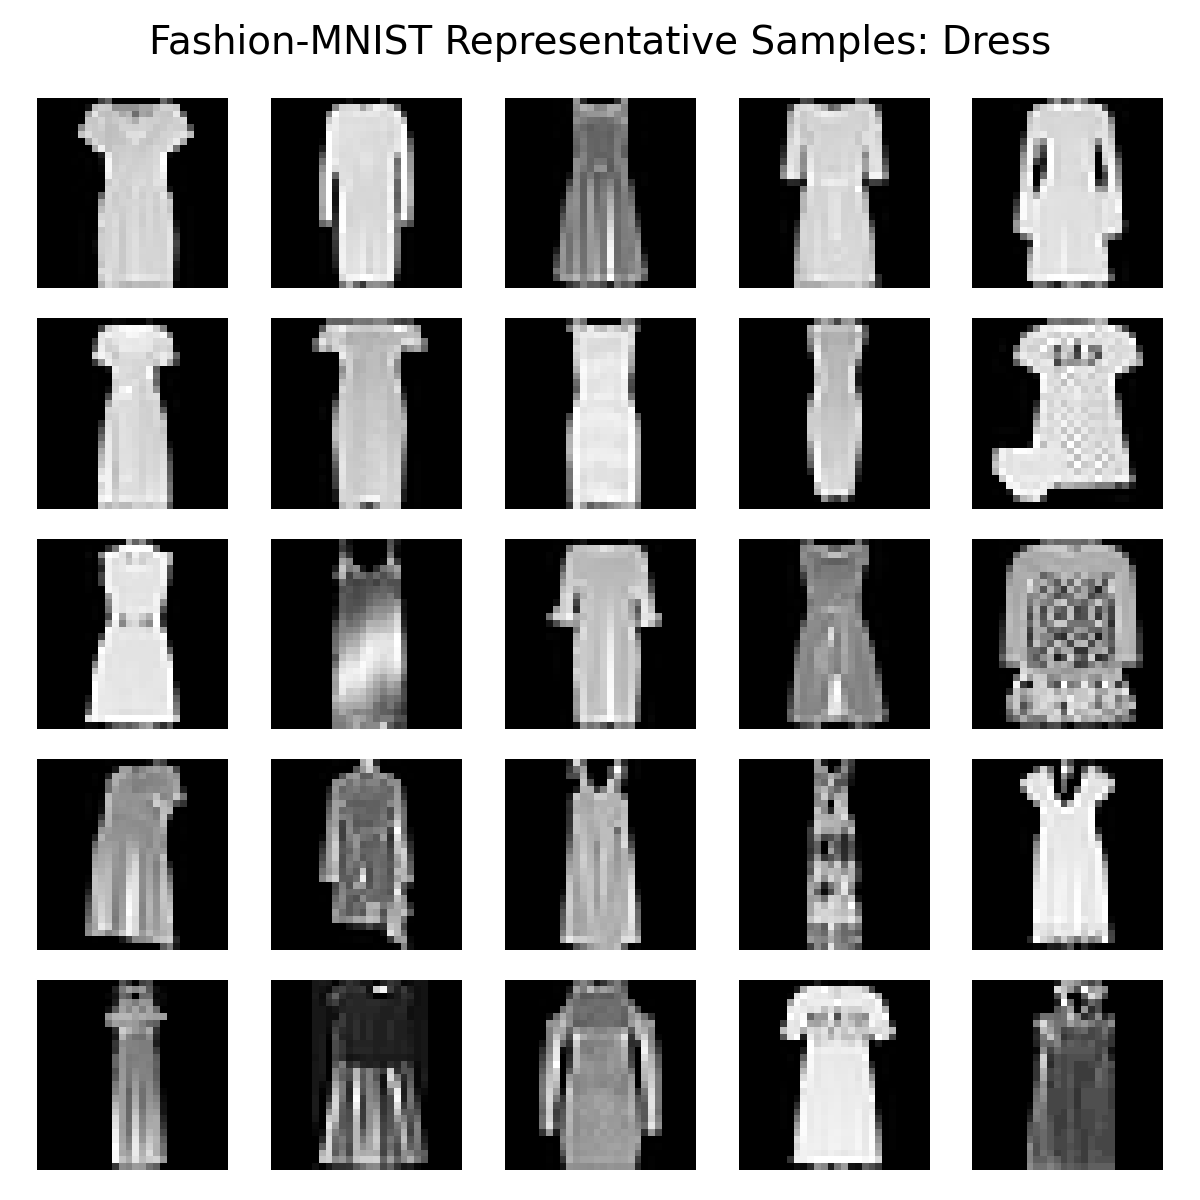


Representative Samples for Class 4:


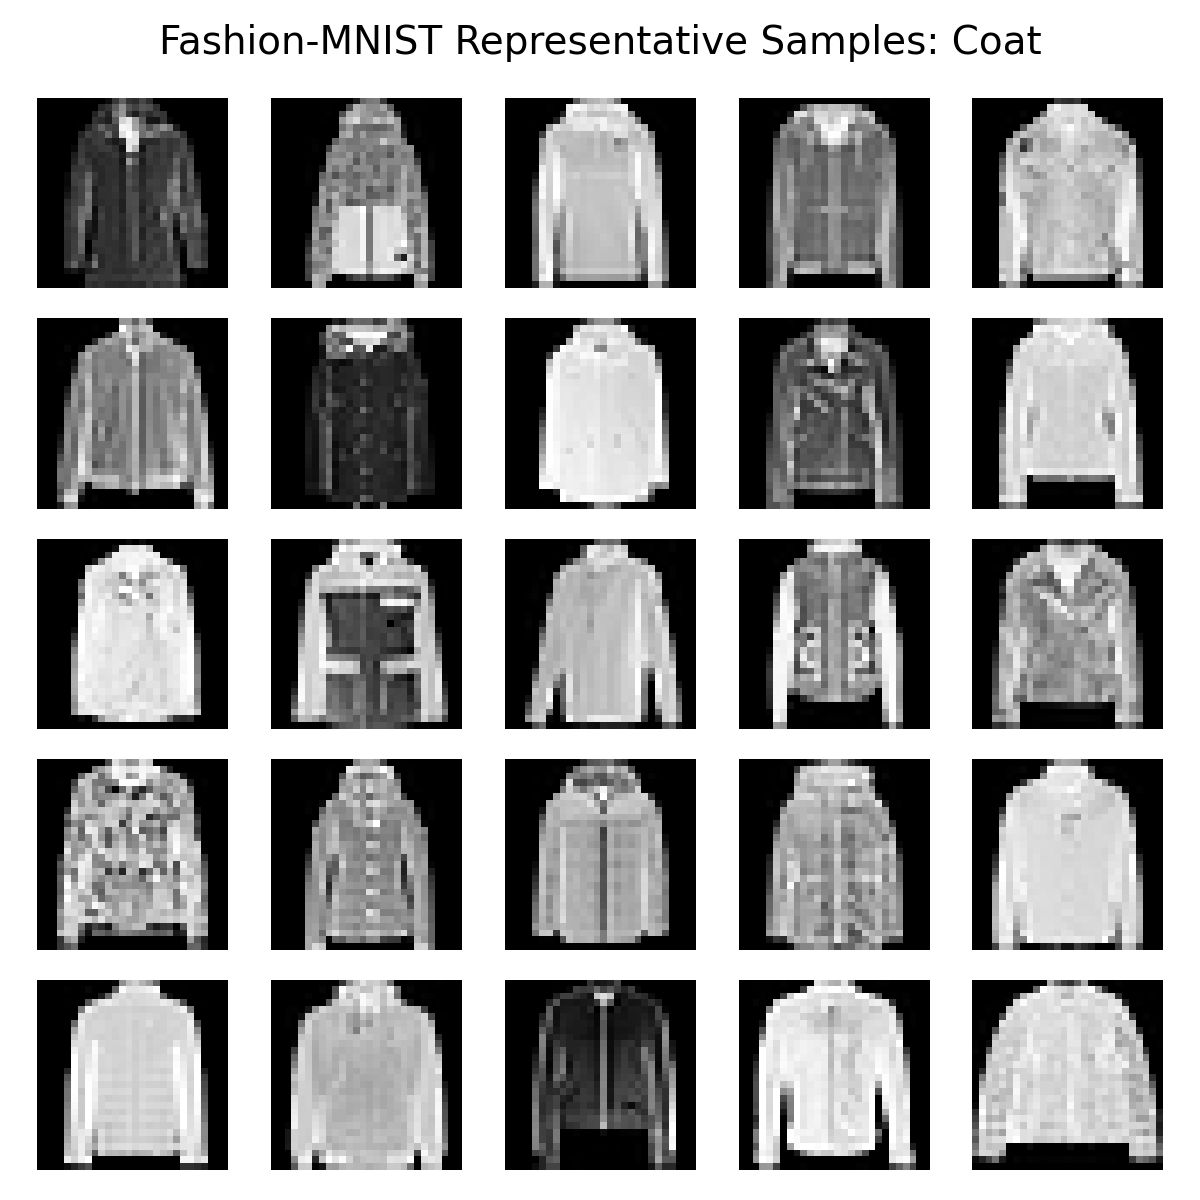


Representative Samples for Class 5:


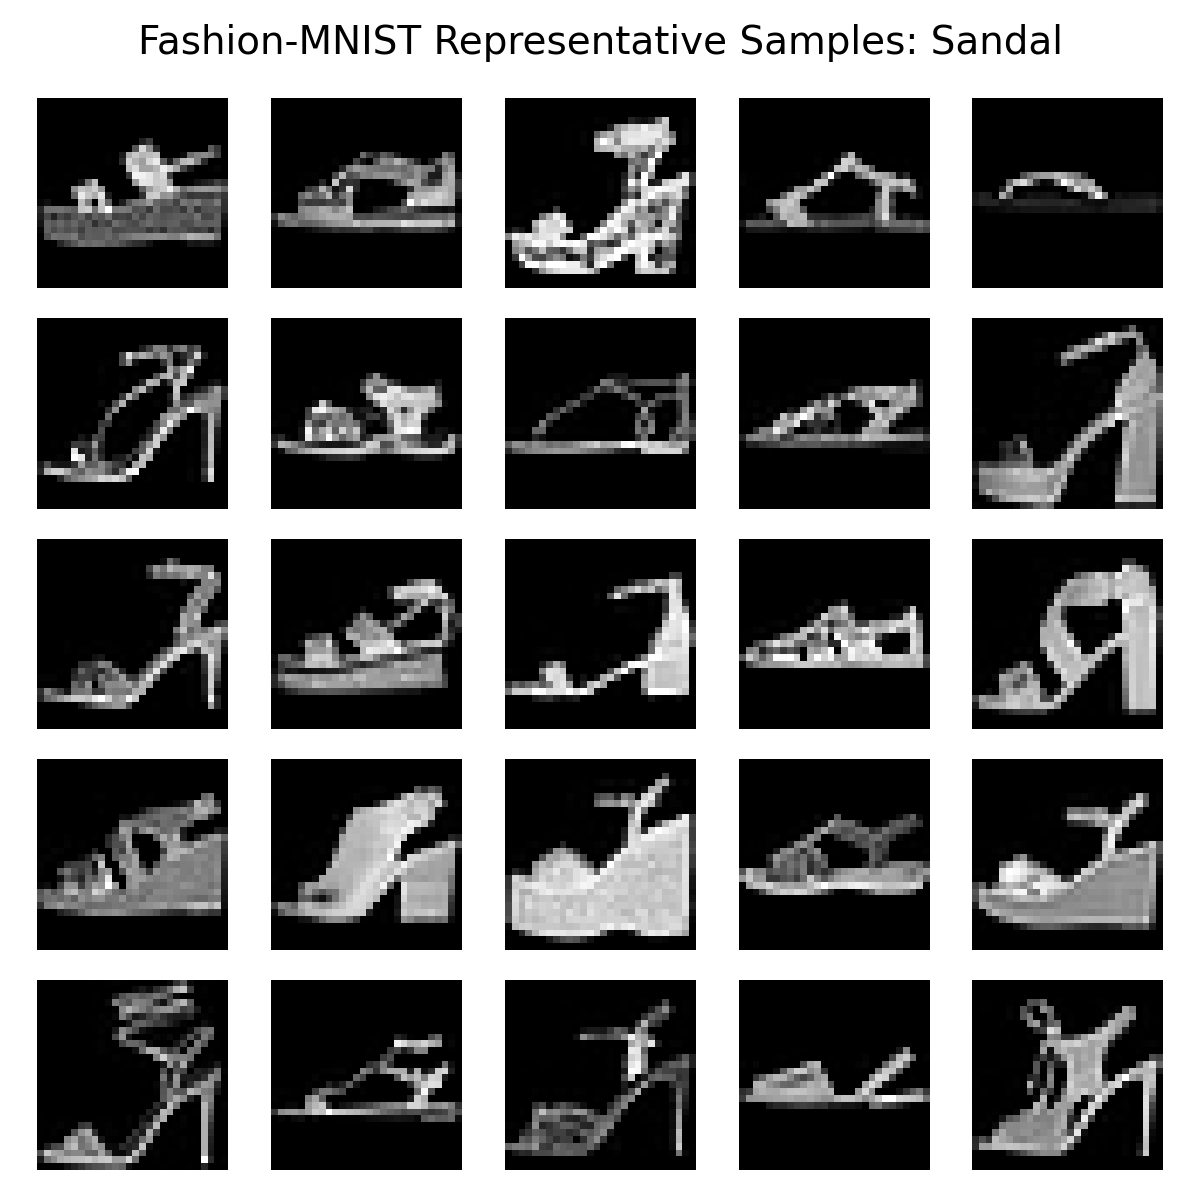


Representative Samples for Class 6:


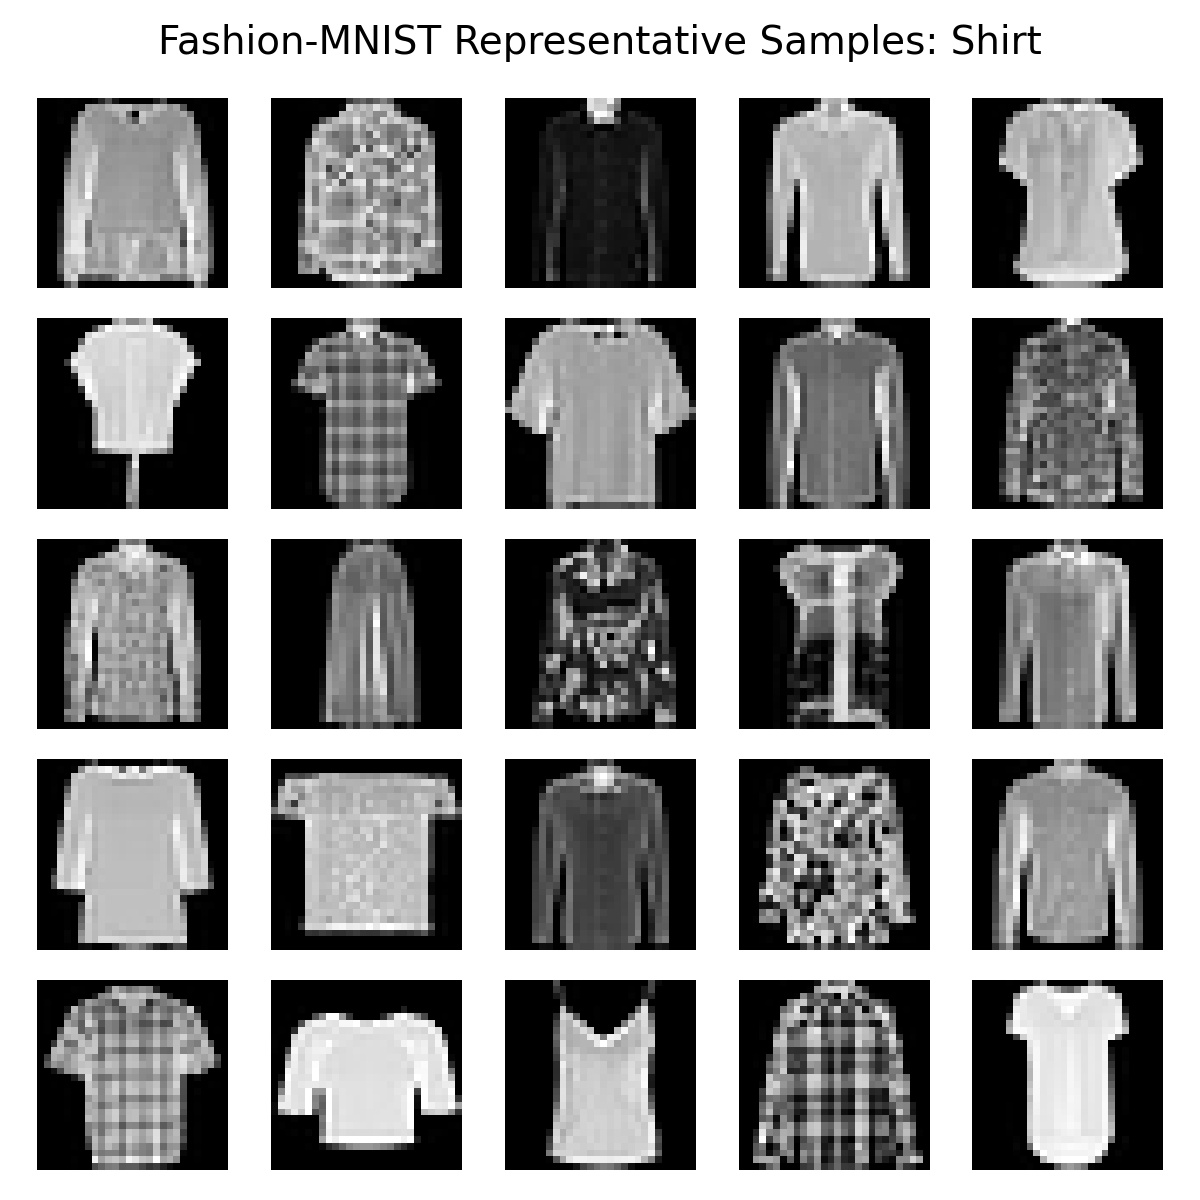


Representative Samples for Class 7:


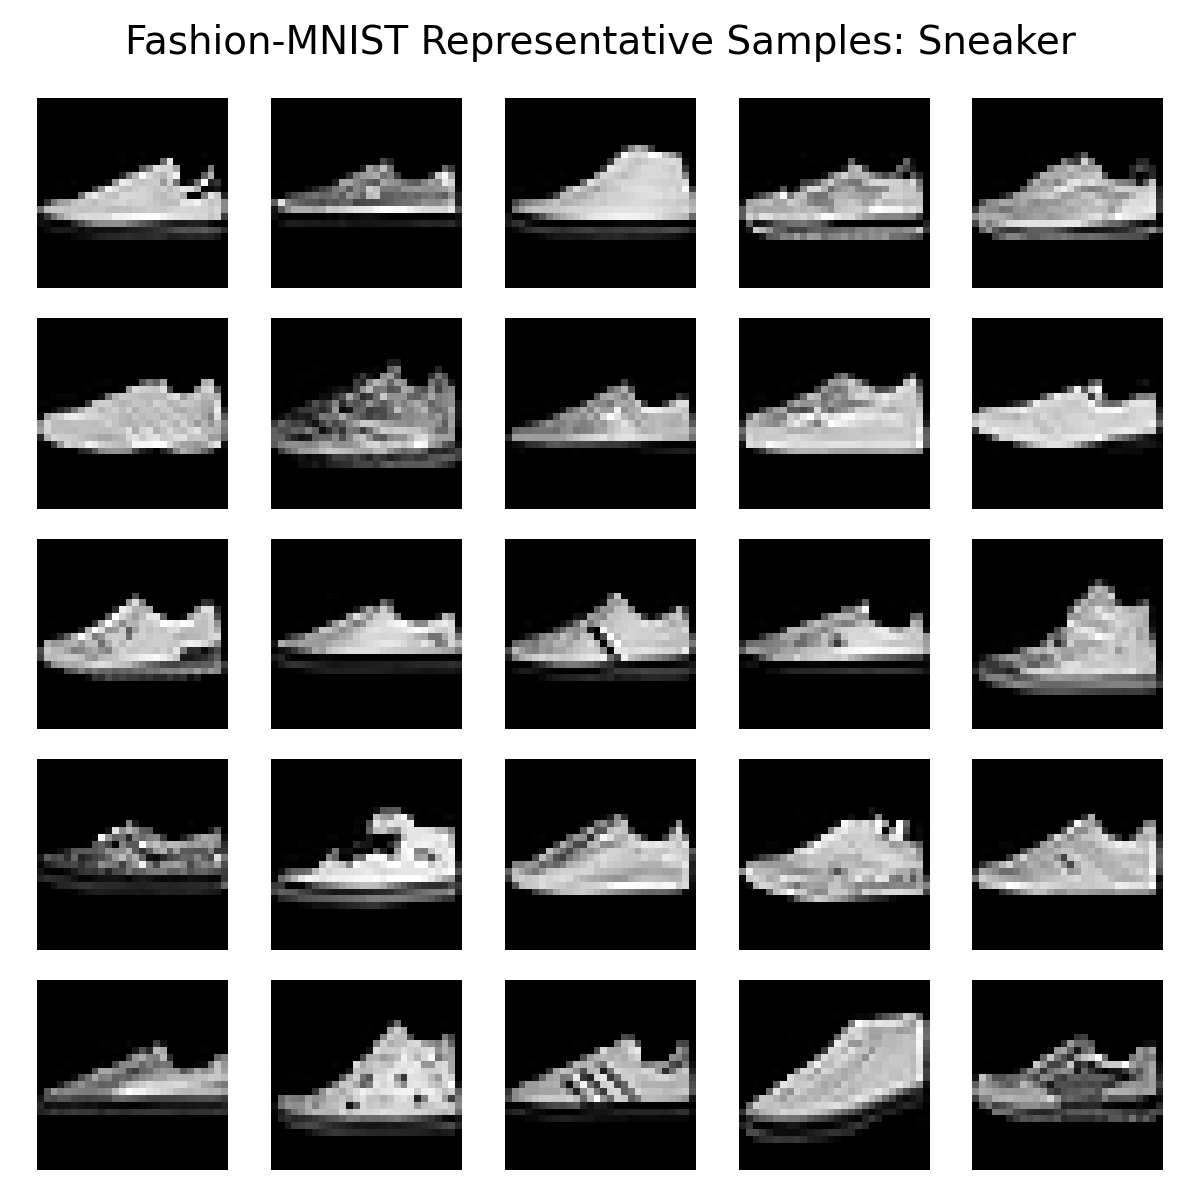


Representative Samples for Class 8:


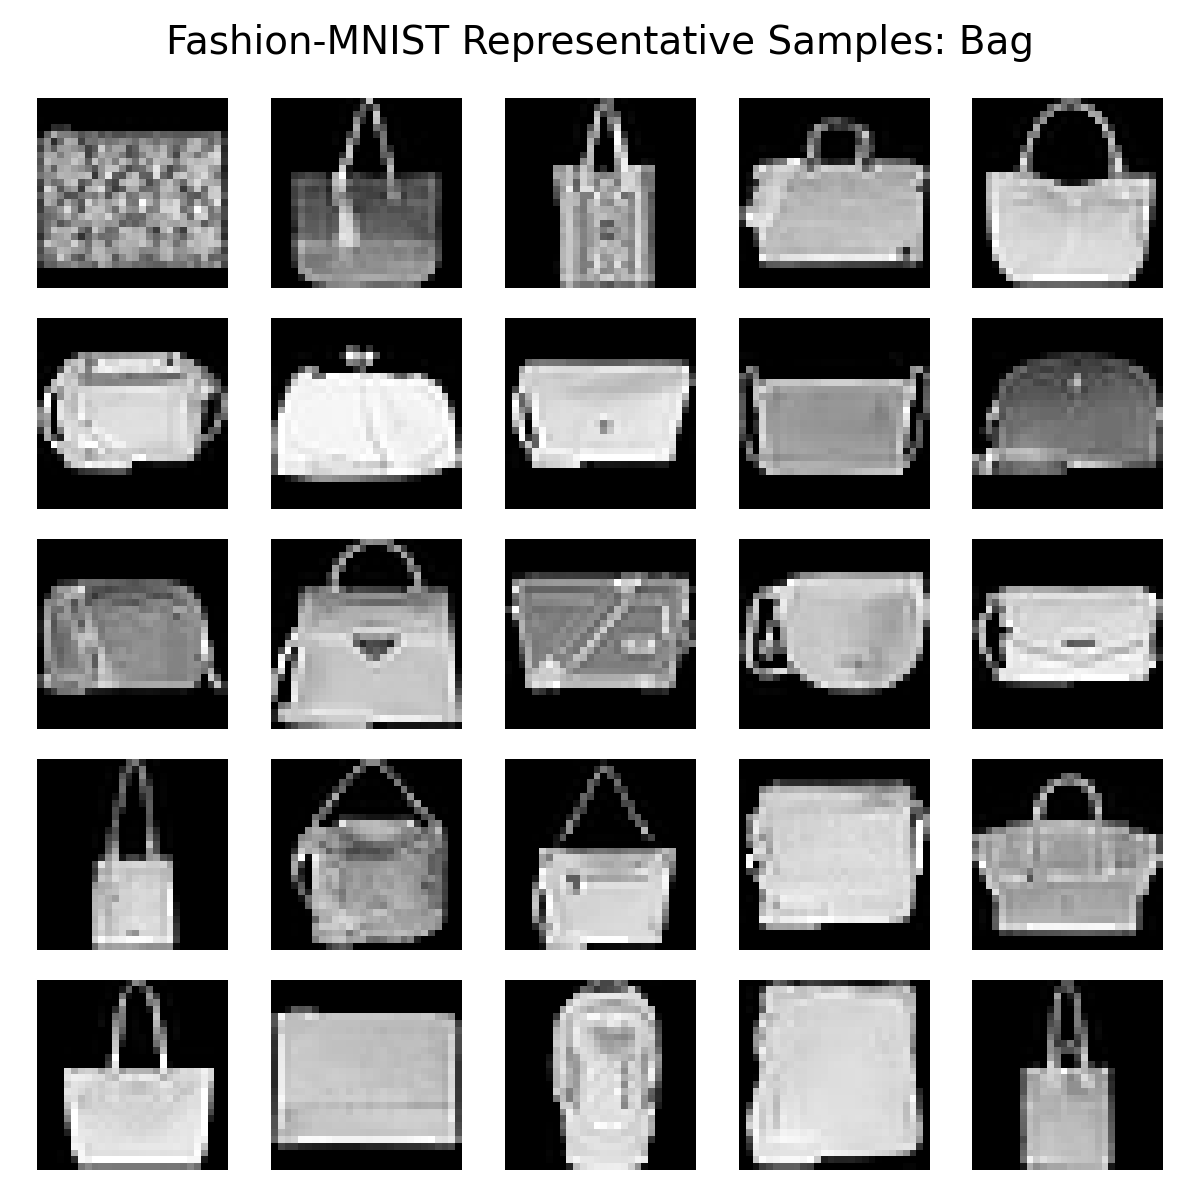


Representative Samples for Class 9:


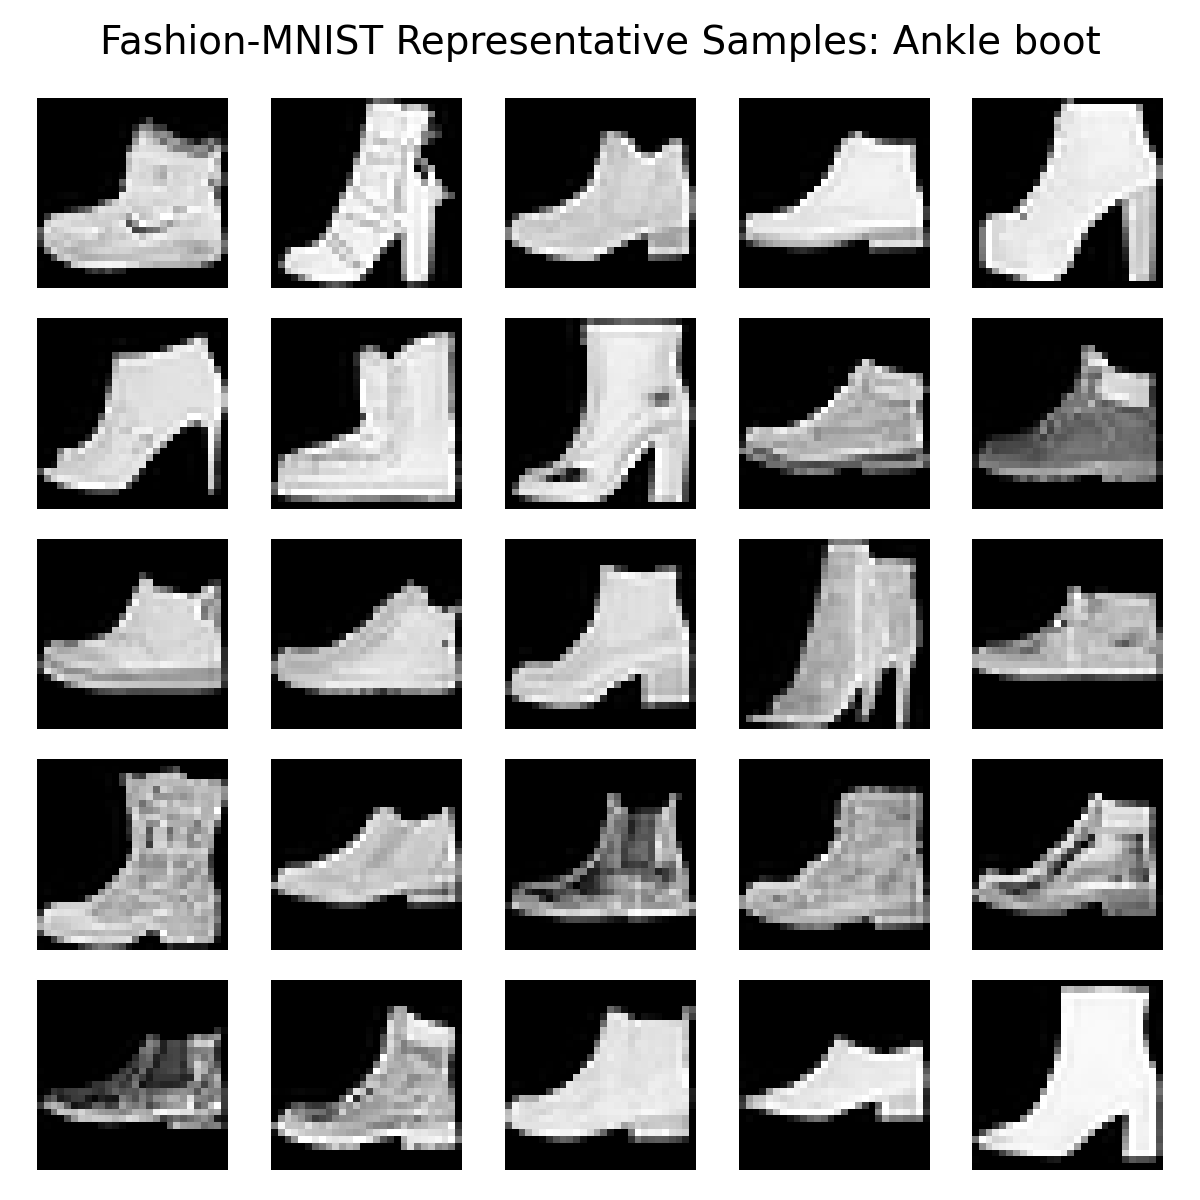

In [ ]:
for i in range(10):
    print(f"\nRepresentative Samples for Class {i}:")
    display(Image(filename=str(eda_output_dir / f"representative_class_{i}.png"), width = 600))

In [ ]:
def show_training_parameters(config):
    buffer = []
    buffer.append(f"Run seed: {config["run"]["seed"]}")
    buffer.append(f"Run device: {config["run"]["device"]}")
    buffer.append(f"Training epochs: {config["budget"]["max_epochs"]}")
    early_stopping_patience = config["training"]["early_stopping_patience"]
    if early_stopping_patience > 0:
        buffer.append(f"Early stopping patience: {early_stopping_patience}")
        buffer.append(f"Early stopping monitor: {config["training"]["early_stopping_monitor"]}")
        buffer.append(f"Early stopping min delta: {config["training"]["min_delta"]}")
    scheduler = config["training"].get("scheduler")
    if bool(scheduler):
        buffer.append(f"Scheduler: {scheduler["name"]}")
    buffer.append(f"")
    return '\n'.join(buffer)

def show_model_parameters(config):
    return config['model']['parameters']

## Train Linear Model

In [ ]:
print("--- Linear Training Parameters ---")
print(show_training_parameters(linear_config))
print()
print("--- Linear Model Parameters ---")
print(json.dumps(show_model_parameters(linear_config), indent=2))

--- Linear Training Parameters ---
Run seed: 69420
Run device: cuda
Training epochs: 200
Early stopping patience: 20
Early stopping monitor: macro_f1
Early stopping min delta: 0.0005
Scheduler: reduce_on_plateau


--- Linear Model Parameters ---
{
  "input_dim": 784,
  "num_classes": 10
}


In [ ]:
# Prepare data
linear_metadata = prepare_data(linear_config)
print("Linear Data Metadata:", json.dumps(linear_metadata, indent=2))

# Build loaders
linear_loaders = build_dataloaders(linear_config)

# Train model
print("\nTraining Linear model...")
linear_fit_result = fit(linear_config, smoke=False)
print(f"\nLinear model training completed. Best checkpoint: {linear_fit_result.best_checkpoint}")

Linear Data Metadata: {
  "dataset": "FashionMNIST",
  "split_seed": 36,
  "split_file": "configs/a1/splits/fashion_mnist_split.json",
  "num_train": 50000,
  "num_val": 10000,
  "num_test": 10000,
  "measured_mean": [
    0.28585961086061534
  ],
  "measured_std": [
    0.352790375749525
  ],
  "classes": [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
  ]
}

Training Linear model...


 22%|██▎       | 45/200 [14:36<50:20, 19.49s/it, val_f1=0.7977, val_loss=0.5694, train_loss=0.6286, lr=1.87e-05, wait=20/20]


Linear model training completed. Best checkpoint: runs/a1/a1_linear_main_seed69420_20260920-114825_3d2881/best.pt


In [ ]:
# Evaluate
linear_eval_result = evaluate_checkpoint(linear_config, linear_fit_result.best_checkpoint, split="validation", smoke=False)
print(f"Linear Model Evaluation Metrics (Validation set):")
print(f"- Loss: {linear_eval_result.metrics.loss}")
print(f"- Accuracy: {linear_eval_result.metrics.accuracy}")
print(f"- Macro F1-Score: {linear_eval_result.metrics.macro_f1}")
print(f"- Samples: {linear_eval_result.metrics.num_samples}")

Linear Model Evaluation Metrics (Validation set):
- Loss: 0.5757788767337799
- Accuracy: 0.8009
- Macro F1-Score: 0.7994872309883585
- Samples: 10000


## Train MLP Model

In [ ]:
print("--- MLP Training Parameters ---")
print(show_training_parameters(mlp_config))
print()
print("--- MLP Model Parameters ---")
print(json.dumps(show_model_parameters(mlp_config), indent=2))

--- MLP Training Parameters ---
Run seed: 69420
Run device: cuda
Training epochs: 200
Early stopping patience: 15
Early stopping monitor: macro_f1
Early stopping min delta: 0.0005
Scheduler: cosine


--- MLP Model Parameters ---
{
  "input_dim": 784,
  "num_classes": 10,
  "hidden_dims": [
    256,
    128
  ],
  "dropout": 0.2,
  "hidden_activation": "relu"
}


In [ ]:
# Prepare data
mlp_metadata = prepare_data(mlp_config)
print("MLP Data Metadata:", json.dumps(mlp_metadata, indent=2))

# Build loaders
mlp_loaders = build_dataloaders(mlp_config)

# Train model
print("\nTraining MLP model...")
mlp_fit_result = fit(mlp_config, smoke=False)
print(f"\nMLP model training completed. Best checkpoint: {mlp_fit_result.best_checkpoint}")

MLP Data Metadata: {
  "dataset": "FashionMNIST",
  "split_seed": 36,
  "split_file": "configs/a1/splits/fashion_mnist_split.json",
  "num_train": 50000,
  "num_val": 10000,
  "num_test": 10000,
  "measured_mean": [
    0.28585961086061534
  ],
  "measured_std": [
    0.352790375749525
  ],
  "classes": [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
  ]
}

Training MLP model...


 32%|███▎      | 65/200 [21:44<45:08, 20.06s/it, val_f1=0.8914, val_loss=0.2921, train_loss=0.3256, lr=3.80e-04, wait=15/15]


MLP model training completed. Best checkpoint: runs/a1/a1_mlp_main_seed69420_20260920-120316_b22d28/best.pt


In [ ]:
# Evaluate
mlp_eval_result = evaluate_checkpoint(mlp_config, mlp_fit_result.best_checkpoint, split="validation", smoke=False)
print(f"MLP Model Evaluation Metrics (Validation set):")
print(f"- Loss: {mlp_eval_result.metrics.loss}")
print(f"- Accuracy: {mlp_eval_result.metrics.accuracy}")
print(f"- Macro F1-Score: {mlp_eval_result.metrics.macro_f1}")
print(f"- Samples: {mlp_eval_result.metrics.num_samples}")

MLP Model Evaluation Metrics (Validation set):
- Loss: 0.28898487813472745
- Accuracy: 0.8951
- Macro F1-Score: 0.8950118764258036
- Samples: 10000


## Hyperparameter Tuning with Optuna
We will install Optuna and use it to find the optimal hyperparameters. Since full runs take too long, we will:
1. Define a search space for learning rate, weight decay, and architecture.
2. Limit each trial to a maximum of 10 epochs.
3. Implement a pruning check: if a trial is performing significantly worse than previous runs, we abort it early.
4. Save the best configuration files to your Google Drive runs directory.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 24.5 MB/s eta 0:00:00


In [ ]:
import optuna
import copy
import json

# Configure Optuna logging level
optuna.logging.set_verbosity(optuna.logging.WARNING)

def tune_linear_model(base_config, n_trials=5):
    def objective(trial):
        # Clone base config so we don't mutate global state
        config = copy.deepcopy(base_config)

        # Suggest hyperparameters
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

        # Override configurations using correct nested structures
        config["training"]["learning_rate"] = lr
        config["training"]["weight_decay"] = weight_decay
        config["training"]["batch_size"] = batch_size
        config["budget"]["max_epochs"] = 20  # Low budget for rapid tuning
        config["training"]["early_stopping_patience"] = 3

        # Train and monitor validation macro_f1
        try:
            fit_result = fit(config, smoke=False)
            # Evaluate best checkpoint on validation set
            eval_result = evaluate_checkpoint(config, fit_result.best_checkpoint, split="validation", smoke=False)
            val_f1 = eval_result.metrics.macro_f1
            return val_f1
        except Exception as e:
            print(f"Trial failed due to: {e}")
            return 0.0

    print("Starting Linear Model Tuning...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("\nLinear Model Tuning Complete!")
    print(f"Best Val F1: {study.best_value:.4f}")
    print("Best Parameters:", json.dumps(study.best_params, indent=2))
    return study.best_params

best_linear_params = tune_linear_model(linear_config, n_trials=10)

Starting Linear Model Tuning...


 65%|██████▌   | 13/20 [04:32<02:26, 20.96s/it, val_f1=0.7884, val_loss=0.5904, train_loss=0.6570, lr=1.32e-04, wait=3/3]



Linear Model Tuning Complete!
Best Val F1: 0.7923
Best Parameters: {
  "lr": 0.0001696037388281409,
  "weight_decay": 0.004205907412140831,
  "batch_size": 64
}


In [ ]:
def tune_mlp_model(base_config, n_trials=5):
    def objective(trial):
        config = copy.deepcopy(base_config)

        # Suggest hyperparameters
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        hidden_dim_1 = trial.suggest_categorical("hidden_dim_1", [128, 256])
        hidden_dim_2 = trial.suggest_categorical("hidden_dim_2", [64, 128])

        # Override configurations using correct nested structures
        config["training"]["learning_rate"] = lr
        config["model"]["parameters"]["dropout"] = dropout
        config["model"]["parameters"]["hidden_dims"] = [hidden_dim_1, hidden_dim_2]
        config["budget"]["max_epochs"] = 20  # Low budget for rapid tuning
        config["training"]["early_stopping_patience"] = 3

        try:
            fit_result = fit(config, smoke=False)
            eval_result = evaluate_checkpoint(config, fit_result.best_checkpoint, split="validation", smoke=False)
            val_f1 = eval_result.metrics.macro_f1
            return val_f1
        except Exception as e:
            print(f"Trial failed due to: {e}")
            return 0.0

    print("Starting MLP Model Tuning...")
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("\nMLP Model Tuning Complete!")
    print(f"Best Val F1: {study.best_value:.4f}")
    print("Best Parameters:", json.dumps(study.best_params, indent=2))
    return study.best_params

best_mlp_params = tune_mlp_model(mlp_config, n_trials=10)

Starting MLP Model Tuning...


 30%|███       | 6/20 [02:01<04:41, 20.14s/it, val_f1=0.8554, val_loss=0.3805, train_loss=0.4482, lr=5.36e-04, wait=1/3]

In [ ]:
# Save the optimal hyperparameters directly into your runs directory (Google Drive)
tuning_output_dir = project_root / "runs" / "hyperparameter_tuning"
tuning_output_dir.mkdir(parents=True, exist_ok=True)

optimal_parameters = {
    "linear_best_params": best_linear_params,
    "mlp_best_params": best_mlp_params
}

output_file = tuning_output_dir / "optimal_hyperparameters.json"
with open(output_file, "w") as f:
    json.dump(optimal_parameters, f, indent=4)

print(f"Optimal hyperparameters saved to Google Drive at: {output_file}")